In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/30.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/29.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/28.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/32 (2).jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/27 (2).jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/31.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/32.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/30 (2).jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/29 (2).jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/27.jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/test/ModerateDemented/28 (2).jpg
/kaggle/input/kaggle-alzheimer-6400/Alzheimer

In [4]:
import os
import cv2
import shutil
import numpy
import numpy as np
from tqdm import tqdm
from numpy import cov
from PIL import Image
from numpy import trace
import tensorflow as tf
from numpy import asarray
from tensorflow import keras
from scipy.linalg import sqrtm
from numpy import iscomplexobj
import matplotlib.pyplot as plt
from numpy.random import randint
from tensorflow.keras import layers
from skimage.transform import resize
from IPython.display import FileLink
from keras.datasets.mnist import load_data
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input
 
# calculate frechet inception distance
def fid_score(batch1, batch2):
    batch1, batch2 = batch1.numpy(), batch2.numpy()
    # scale an array of images to a new size
    def scale_images(images, new_shape):
        images_list = list()
        for image in images:
            # resize with nearest neighbor interpolation
            new_image = resize(image, new_shape, 0)
            # store
            images_list.append(new_image)
        return asarray(images_list)
    # prepare the inception v3 model
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))
    # resize images
    batch1 = scale_images(batch1, (299,299,3))
    batch2 = scale_images(batch2, (299,299,3))
    # pre-process images
    batch1 = preprocess_input(batch1)
    batch2 = preprocess_input(batch2)
    # calculate feature embeddings
    embedding1 = model.predict(batch1)
    embedding2 = model.predict(batch2)
    # calculate mean and covariance statistics
    mu1, sigma1 = embedding1.mean(axis=0), cov(embedding1, rowvar=False)
    mu2, sigma2 = embedding2.mean(axis=0), cov(embedding2, rowvar=False)
    # calculate sum squared difference between means
    ssdiff = numpy.sum((mu1 - mu2)**2.0)
    # calculate sqrt of product between cov
    covmean = sqrtm(sigma1.dot(sigma2))
    # check and correct imaginary numbers from sqrt
    if iscomplexobj(covmean):
        covmean = covmean.real
    # calculate fid score
    fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

ModuleNotFoundError: No module named 'cv2'

In [66]:
from PIL import Image
import numpy as np
path = '/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/train/MildDemented/'
path_list = os.listdir(path)
mild_demented_images = []
file_name = []
for j in path_list:
    if '.jpg'  in j:
        file_name.append(j)
        img = cv2.imread(j,cv2.IMREAD_GRAYSCALE)
        mild_demented_images.append(image)

In [67]:
from PIL import Image
import numpy as np
path = '/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/train/VeryMildDemented/'
path_list = os.listdir(path)
very_mild_demented_images = []
file_name = []
for j in path_list:
    if '.jpg'  in j:
        file_name.append(j)
        img = cv2.imread(j,cv2.IMREAD_GRAYSCALE)
        very_mild_demented_images.append(image)

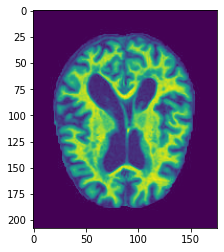

In [42]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/train/MildDemented/mildDem557.jpg',cv2.IMREAD_GRAYSCALE)
plt.imshow(img)

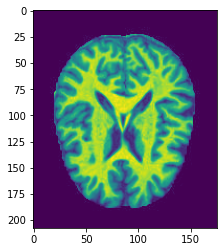

In [73]:
img = cv2.imread('/kaggle/input/kaggle-alzheimer-6400/Alzheimer_s Dataset/train/VeryMildDemented/verymildDem1483.jpg',cv2.IMREAD_GRAYSCALE)
plt.imshow(img)

In [68]:
mild_demented_images = np.array(mild_demented_images)
very_mild_demented_images = np.array(very_mild_demented_images)

In [83]:
batch1 = mild_demented_images[:64]
batch2 = very_mild_demented_images[130:194]
fid_score(batch1,batch2)

0.0

In [84]:
from keras.datasets import cifar10
(images1, _), (images2, _) = cifar10.load_data()
batch1 = images1[:64]
batch2 = very_mild_demented_images[:64]
fid_score(batch1,batch2)

572.2835360470144

In [1]:
5%200

5